## 1. Environment Setup

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
# import sys
from dotenv import load_dotenv
load_dotenv()

DATA_SOURCE_PATH = os.getenv("DATA_SOURCE_PATH", "../data/raw/")

#Add the path for the feature-engineered data
DATA_PROCESSED_PATH = os.getenv("DATA_PROCESSED_PATH", "../data/processed/")    
X_TRAIN_DATA_FILENAME = os.getenv("X_TRAIN_DATA_FILENAME", "X_train.csv")
X_TEST_DATA_FILENAME = os.getenv("X_TEST_DATA_FILENAME", "X_test.csv")
Y_TRAIN_LOG_DATA_FILENAME = os.getenv("Y_TRAIN_LOG_DATA_FILENAME", "y_train_log.csv")
Y_TEST_LOG_DATA_FILENAME = os.getenv("Y_TEST_LOG_DATA_FILENAME", "y_test_log.csv")
Y_TRAIN_ACTUAL_DATA_FILENAME = os.getenv("Y_TRAIN_ACTUAL_DATA_FILENAME", "y_train_actual.csv")
Y_TEST_ACTUAL_DATA_FILENAME = os.getenv("Y_TEST_ACTUAL_DATA_FILENAME", "y_test_actual.csv")
SOURCE_PATH = os.getenv("SOURCE_PATH", "../src/")

# Add src to path for custom modules
# sys.path.append(SOURCE_PATH)

# Set style
plt.style.use('default')
sns.set_palette("husl")

print("✅ Environment setup complete!")


✅ Environment setup complete!


## 2. Load Data

In [2]:
# Load your feature-engineered dataset
data_path = Path(DATA_PROCESSED_PATH)
X_train = pd.read_csv(data_path / X_TRAIN_DATA_FILENAME)
X_test = pd.read_csv(data_path / X_TEST_DATA_FILENAME)
y_train_log = pd.read_csv(data_path / Y_TRAIN_LOG_DATA_FILENAME)
y_test_log = pd.read_csv(data_path / Y_TEST_LOG_DATA_FILENAME)
y_train_actual = pd.read_csv(data_path / Y_TRAIN_ACTUAL_DATA_FILENAME)
y_test_actual = pd.read_csv(data_path / Y_TEST_ACTUAL_DATA_FILENAME)


# Print the dataset shape for X_train and X_test,Y_train_log, y_train_actual, y_test_actual

print(f"Dataset shape: {X_train.shape}")
print(f"Dataset shape: {X_test.shape}")
print(f"Dataset shape: {y_train_log.shape}")
print(f"Dataset shape: {y_test_log.shape}")
print(f"Dataset shape: {y_train_actual.shape}")
print(f"Dataset shape: {y_test_actual.shape}")  

#print columns of the dataset for X_train and X_test, y_train_log, y_train_actual, y_test_actual
print("\n--- Dataset Columns ---")
print(X_train.columns)
print(X_test.columns)
print(y_train_log.columns)
print(y_test_log.columns)
print(y_train_actual.columns)
print(y_test_actual.columns)    



Dataset shape: (3681, 17)
Dataset shape: (921, 17)
Dataset shape: (3681, 1)
Dataset shape: (921, 1)
Dataset shape: (3681, 1)
Dataset shape: (921, 1)

--- Dataset Columns ---
Index(['log_sqft_living', 'log_sqft_lot', 'log_sqft_basement',
       'sqft_per_bedroom', 'basement_ratio', 'bedrooms_per_sqft',
       'bathrooms_per_sqft', 'house_age', 'floors', 'view', 'condition',
       'renovated', 'bath_x_living', 'waterfront_x_living', 'city_price_index',
       'statezip_price_index', 'knn_price'],
      dtype='object')
Index(['log_sqft_living', 'log_sqft_lot', 'log_sqft_basement',
       'sqft_per_bedroom', 'basement_ratio', 'bedrooms_per_sqft',
       'bathrooms_per_sqft', 'house_age', 'floors', 'view', 'condition',
       'renovated', 'bath_x_living', 'waterfront_x_living', 'city_price_index',
       'statezip_price_index', 'knn_price'],
      dtype='object')
Index(['log_price'], dtype='object')
Index(['log_price'], dtype='object')
Index(['price'], dtype='object')
Index(['price'], dtyp

## 3. X variables Check

In [3]:
# Align columns just in case
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

# y_train = train_df['log_price']
# y_test = test_df['log_price']
# train_price = train_df['price']
# test_price = test_df['price']

print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)
print('Number of features:', X_train.shape[1])
print(X_test.head()) 
print (X_train.head())

X_train shape: (3681, 17)
X_test shape: (921, 17)
Number of features: 17
   log_sqft_living  log_sqft_lot  log_sqft_basement  sqft_per_bedroom  \
0         7.286876      7.386471           5.638355             365.0   
1         8.033009      9.431642           0.000000             770.0   
2         7.986505      8.600247           6.216606             735.0   
3         7.696667      8.902592           6.447306             550.0   
4         7.450661      9.077494           6.580639             430.0   

   basement_ratio  bedrooms_per_sqft  bathrooms_per_sqft  house_age  floors  \
0        0.191650           0.002053            0.001711          7     2.0   
1        0.000000           0.000974            0.000811         24     2.0   
2        0.170010           0.001020            0.001105         36     3.0   
3        0.286234           0.001363            0.001136         26     1.0   
4        0.418361           0.001743            0.001453         31     1.0   

   view  cond

In [4]:
from sklearn.preprocessing import StandardScaler

# These three features are in dollar scale (100k–900k)
# while all other features are small numbers (0–800)
# This mismatch destabilises XGBoost hyperparameter search
large_cols = ['city_price_index', 'statezip_price_index', 'knn_price']

scaler = StandardScaler()
X_train[large_cols] = scaler.fit_transform(X_train[large_cols])
X_test[large_cols]  = scaler.transform(X_test[large_cols])  # use same scaler, never fit on test

print("After scaling:")
print(X_train[large_cols].describe().round(3))

After scaling:
       city_price_index  statezip_price_index  knn_price
count          3681.000              3681.000   3681.000
mean             -0.000                -0.000     -0.000
std               1.000                 1.000      1.000
min              -2.145                -1.778     -1.387
25%              -0.826                -0.809     -0.683
50%               0.129                -0.002     -0.276
75%               0.401                 0.434      0.401
max               7.428                 5.557      5.517


## 4. Evaluation 

In [5]:
# Baseline and regularized linear models
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, ElasticNetCV
from sklearn.metrics import mean_absolute_percentage_error

# Function to evaluate models
def evaluate_log_model(model, X_train, y_train_log, X_test, y_test_actual, y_train_actual, fit_model=True):
    # Force 1D on everything
    y_train_log    = np.ravel(y_train_log)
    y_train_actual = np.ravel(y_train_actual)
    y_test_actual  = np.ravel(y_test_actual)

    if fit_model:
        model.fit(X_train, y_train_log)

    pred_price_train = np.exp(np.clip(model.predict(X_train), 5, 20))
    pred_price_test  = np.exp(np.clip(model.predict(X_test),  5, 20))

    train_mape = mean_absolute_percentage_error(y_train_actual, pred_price_train)
    test_mape  = mean_absolute_percentage_error(y_test_actual,  pred_price_test)

    return train_mape, test_mape



## 5. Target Preparation

In [6]:
# Flatten targets once — used by all downstream cells
y_train_log_1d    = np.ravel(y_train_log)
y_train_actual_1d = np.ravel(y_train_actual)
y_test_actual_1d  = np.ravel(y_test_actual)

print(f"y_train_log range   : {y_train_log_1d.min():.2f} – {y_train_log_1d.max():.2f}  (expected ~11–14 for log-prices)")
print(f"y_train_actual range: ${y_train_actual_1d.min():,.0f} – ${y_train_actual_1d.max():,.0f}")
print(f"y_test_actual  range: ${y_test_actual_1d.min():,.0f} – ${y_test_actual_1d.max():,.0f}")


y_train_log range   : 11.87 – 14.51  (expected ~11–14 for log-prices)
y_train_actual range: $142,550 – $2,004,950
y_test_actual  range: $142,550 – $2,004,950


## 6. Randomised Hyperparameter Search

In [7]:
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import make_scorer, mean_absolute_percentage_error
import numpy as np

# ── 1. Parameter space covering all four key axes ──────────────────────────
param_dist = {
    'max_depth'       : [3, 4, 5, 6, 7],
    'learning_rate'   : [0.01, 0.03, 0.05, 0.07, 0.1],
    'n_estimators'    : [200, 500, 800, 1000, 1500, 2000],
    'subsample'       : [0.7, 0.75, 0.8, 0.85, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
}

BASE_SCORE = float(y_train_log_1d.mean())

# ── 2. Custom scorer: MAPE in actual dollar space ──────────────────────────
# RandomizedSearchCV fits on log-prices and passes log-price predictions to
# the scorer.  We exp()-convert both sides so CV MAPE is directly comparable
# to the sensitivity-plot Test MAPE (both measured in actual dollars).
def dollar_mape_scorer(y_true_log, y_pred_log):
    """Convert log predictions → dollars, then compute MAPE."""
    y_true_dollars = np.exp(np.clip(y_true_log, 5, 20))
    y_pred_dollars = np.exp(np.clip(y_pred_log, 5, 20))
    return mean_absolute_percentage_error(y_true_dollars, y_pred_dollars)

dollar_mape = make_scorer(dollar_mape_scorer, greater_is_better=False)

xgb_base = XGBRegressor(
    objective    = 'reg:pseudohubererror',
    base_score   = BASE_SCORE,
    random_state = 42,
    n_jobs       = 1,
    verbosity    = 0,
)

random_search = RandomizedSearchCV(
    estimator           = xgb_base,
    param_distributions = param_dist,
    n_iter              = 50,
    cv                  = 5,
    scoring             = dollar_mape,   # CV MAPE now in actual dollar space
    random_state        = 42,
    n_jobs              = -1,
    verbose             = 1,
    refit               = True,
)

print("Running RandomizedSearchCV (50 candidates × 5 folds = 250 fits)…")
print("Scoring: MAPE in actual dollar space (exp-converted)")
random_search.fit(X_train, y_train_log_1d)

best_params = random_search.best_params_
print("\n✅ Best hyperparameters found:")
for k, v in sorted(best_params.items()):
    print(f"   {k:<22}: {v}")

# ── 3. Evaluate best model in actual-dollar space ─────────────────────────
best_xgb = random_search.best_estimator_

train_mape, test_mape = evaluate_log_model(
    best_xgb, X_train, y_train_log_1d, X_test, y_test_actual_1d, y_train_actual_1d,
    fit_model=False
)

print(f"\nBest XGBoost — Final Evaluation (actual dollar space)")
print(f"  Train MAPE : {train_mape*100:.2f}%")
print(f"  Test  MAPE : {test_mape*100:.2f}%")
print(f"  (CV MAPE from search should now be close to Test MAPE above)")

best_row = {
    'Learning_Rate': str(best_params['learning_rate']),
    'N_Estimators' : best_params['n_estimators'],
    'Train_MAPE%'  : train_mape * 100,
    'Test_MAPE%'   : test_mape  * 100,
}
best_xgb_model = best_xgb


Running RandomizedSearchCV (50 candidates × 5 folds = 250 fits)…
Scoring: MAPE in actual dollar space (exp-converted)
Fitting 5 folds for each of 50 candidates, totalling 250 fits

✅ Best hyperparameters found:
   colsample_bytree      : 0.8
   learning_rate         : 0.01
   max_depth             : 7
   n_estimators          : 800
   subsample             : 0.75

Best XGBoost — Final Evaluation (actual dollar space)
  Train MAPE : 9.35%
  Test  MAPE : 24.11%
  (CV MAPE from search should now be close to Test MAPE above)


## 7. Results: Top-10 Configurations & Sensitivity Plot

Top 10 configurations (CV MAPE = dollar-space, directly comparable to Test MAPE):
   max_depth learning_rate n_estimators subsample colsample_bytree   CV_MAPE%
1          7          0.01          800      0.75              0.8  19.323295
2          6          0.01          800       0.7              0.7  19.338957
3          7          0.01         1000      0.85              0.9  19.362251
4          5          0.01         1500      0.85              0.8  19.375807
5          7          0.03          500      0.75              0.8  19.421238
6          6          0.01         1500       0.8              0.7  19.424613
7          7          0.03          200       0.8              0.8  19.427828
8          6          0.01          800       0.9              0.9  19.451484
9          7          0.03          500      0.85              1.0  19.464325
10         6          0.03          200       0.7              1.0  19.467748

Running sensitivity grid: 18 fits (depth=7, ss=0.75, cs=0.8

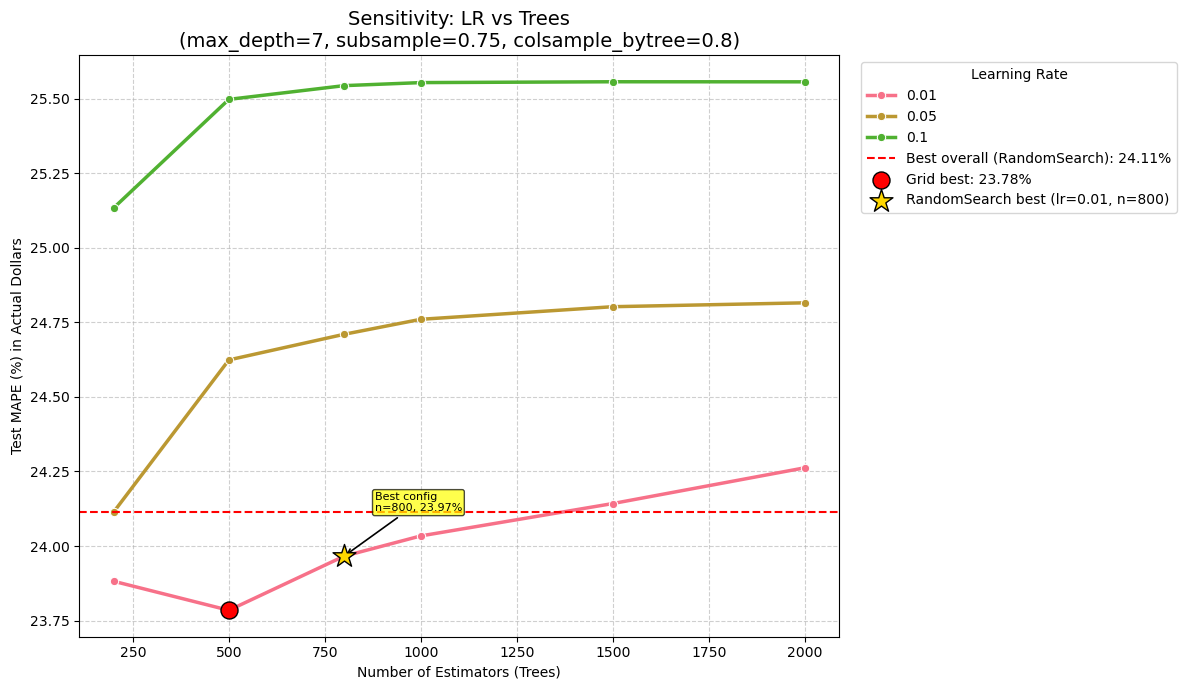


Best configuration (RandomizedSearchCV):
  max_depth=7, learning_rate=0.01, n_estimators=800, subsample=0.75, colsample_bytree=0.8
  Test MAPE: 24.11%


In [8]:
# ── 3. Top-10 configurations from the search ──────────────────────────────
cv_results = (
    pd.DataFrame(random_search.cv_results_)
    [['param_max_depth', 'param_learning_rate', 'param_n_estimators',
      'param_subsample', 'param_colsample_bytree', 'mean_test_score', 'rank_test_score']]
    .sort_values('rank_test_score')
    .reset_index(drop=True)
)
cv_results['CV_MAPE%'] = -cv_results['mean_test_score'] * 100  # dollar-space MAPE %

print("Top 10 configurations (CV MAPE = dollar-space, directly comparable to Test MAPE):")
top10_display = cv_results[['param_max_depth', 'param_learning_rate',
                             'param_n_estimators', 'param_subsample',
                             'param_colsample_bytree', 'CV_MAPE%']].head(10).copy()
top10_display.columns = ['max_depth', 'learning_rate', 'n_estimators',
                          'subsample', 'colsample_bytree', 'CV_MAPE%']
top10_display.index = range(1, 11)
print(top10_display.to_string())

# ── 4. Sensitivity plot: LR vs n_estimators at best depth/subsample ───────
import itertools

best_depth     = best_params['max_depth']
best_subsample = best_params['subsample']
best_col       = best_params.get('colsample_bytree', 0.8)
learning_rates = [0.01, 0.05, 0.1]
n_est_range    = [200, 500, 800, 1000, 1500, 2000]

sensitivity_results = []
total = len(learning_rates) * len(n_est_range)
print(f"\nRunning sensitivity grid: {total} fits "
      f"(depth={best_depth}, ss={best_subsample}, cs={best_col})...")

for i, (lr, n_est) in enumerate(itertools.product(learning_rates, n_est_range), 1):
    m = XGBRegressor(
        objective        = 'reg:squarederror',  # stable for individual fits
        base_score       = float(y_train_log_1d.mean()),
        max_depth        = best_depth,
        subsample        = best_subsample,
        learning_rate    = lr,
        n_estimators     = n_est,
        colsample_bytree = best_col,
        random_state     = 42, n_jobs=-1, verbosity=0,
    )
    tr_m, te_m = evaluate_log_model(
        m, X_train, y_train_log_1d, X_test, y_test_actual_1d, y_train_actual_1d
    )
    sensitivity_results.append({'Learning_Rate': str(lr), 'N_Estimators': n_est,
                                 'Train_MAPE%': tr_m*100, 'Test_MAPE%': te_m*100})
    print(f"  [{i:>2}/{total}] lr={lr}, n={n_est:>4}  "
          f"→  Test MAPE={te_m*100:.2f}%")

tuning_df = pd.DataFrame(sensitivity_results)

plt.figure(figsize=(12, 7))
sns.lineplot(data=tuning_df, x='N_Estimators', y='Test_MAPE%',
             hue='Learning_Rate', marker='o', linewidth=2.5)
plt.axhline(test_mape*100, color='red', linestyle='--', linewidth=1.5,
            label=f'Best overall (RandomSearch): {test_mape*100:.2f}%')

# Red dot: sensitivity grid's own minimum
best_sens = tuning_df.loc[tuning_df['Test_MAPE%'].idxmin()]
plt.scatter(best_sens['N_Estimators'], best_sens['Test_MAPE%'],
            color='red', s=150, edgecolors='black', zorder=5,
            label=f"Grid best: {best_sens['Test_MAPE%']:.2f}%")

# Gold star: RandomizedSearch best config (lr + n_estimators)
best_lr_str = str(float(best_params['learning_rate']))
best_n      = best_params['n_estimators']
best_point  = tuning_df[
    (tuning_df['Learning_Rate'] == best_lr_str) &
    (tuning_df['N_Estimators']  == best_n)
]
best_lr_str = str(best_params['learning_rate'])
best_point  = tuning_df[
    (tuning_df['Learning_Rate'] == best_lr_str) &
    (tuning_df['N_Estimators']  == best_n)
]
if not best_point.empty:
    bx = float(best_point['N_Estimators'].values[0])
    by = float(best_point['Test_MAPE%'].values[0])
    plt.scatter(bx, by, color='gold', s=300, edgecolors='black',
                zorder=7, marker='*',
                label=f"RandomSearch best (lr={best_params['learning_rate']}, n={best_n})")
    plt.annotate(
        f"Best config\nn={best_n}, {by:.2f}%",
        xy=(bx, by), xytext=(bx + 80, by + 0.15),
        arrowprops=dict(arrowstyle='->', color='black', lw=1.2),
        fontsize=8, ha='left',
        bbox=dict(boxstyle='round,pad=0.2', fc='yellow', alpha=0.7)
    )
else:
    plt.axvline(best_n, color='gold', linestyle=':', linewidth=2,
                label=f"RandomSearch best n={best_n} (not in grid)")

plt.title(f'Sensitivity: LR vs Trees\n'
          f'(max_depth={best_depth}, subsample={best_subsample}, '
          f'colsample_bytree={best_col})', fontsize=14)
plt.xlabel('Number of Estimators (Trees)')
plt.ylabel('Test MAPE (%) in Actual Dollars')
plt.legend(title='Learning Rate', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print(f"\nBest configuration (RandomizedSearchCV):")
print(f"  max_depth={best_params['max_depth']}, "
      f"learning_rate={best_params['learning_rate']}, "
      f"n_estimators={best_params['n_estimators']}, "
      f"subsample={best_params['subsample']}, "
      f"colsample_bytree={best_col}")
print(f"  Test MAPE: {test_mape*100:.2f}%")


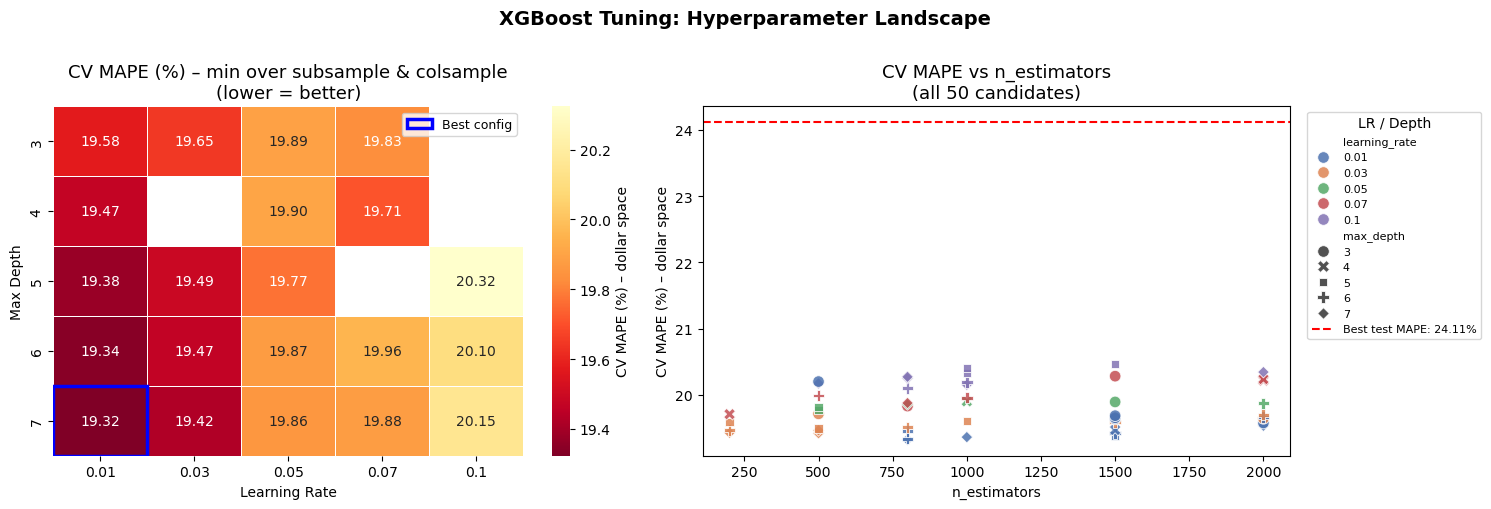

Heatmap saved to xgb_tuning_heatmap.png


In [9]:
# ============================================================
# Tuning heatmap: CV MAPE by max_depth × learning_rate
# Source: cv_results from RandomizedSearchCV (50 candidates)
# ============================================================

# Build a clean numeric copy from cv_results
heatmap_df = cv_results[["param_max_depth", "param_learning_rate",
                          "param_n_estimators", "CV_MAPE%"]].copy()
heatmap_df.columns = ["max_depth", "learning_rate", "n_estimators", "CV_MAPE%"]
heatmap_df["max_depth"]    = heatmap_df["max_depth"].astype(int)
heatmap_df["learning_rate"]= heatmap_df["learning_rate"].astype(float)
heatmap_df["n_estimators"] = heatmap_df["n_estimators"].astype(int)

# Pivot: rows = max_depth, cols = learning_rate
# Cell value = best (min) CV MAPE across all subsample / colsample combos
pivot = (heatmap_df
         .groupby(["max_depth", "learning_rate"])["CV_MAPE%"]
         .min()
         .unstack())

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ── Left: heatmap ─────────────────────────────────────────────────────────
sns.heatmap(
    pivot, annot=True, fmt=".2f", cmap="YlOrRd_r",
    linewidths=0.5, ax=axes[0],
    cbar_kws={"label": "CV MAPE (%) – dollar space"}
)
axes[0].set_title("CV MAPE (%) – min over subsample & colsample\n(lower = better)",
                  fontsize=13)
axes[0].set_xlabel("Learning Rate")
axes[0].set_ylabel("Max Depth")

# Mark the best cell
best_lr    = float(best_params["learning_rate"])
best_depth = int(best_params["max_depth"])
if best_lr in pivot.columns and best_depth in pivot.index:
    col_idx = list(pivot.columns).index(best_lr)
    row_idx = list(pivot.index).index(best_depth)
    axes[0].add_patch(plt.Rectangle(
        (col_idx, row_idx), 1, 1,
        fill=False, edgecolor="blue", lw=2.5, label="Best config"
    ))
axes[0].legend(loc="upper right", fontsize=9)

# ── Right: scatter — n_estimators vs CV MAPE, coloured by learning_rate ───
scatter_palette = sns.color_palette("deep", n_colors=heatmap_df["learning_rate"].nunique())
sns.scatterplot(
    data=heatmap_df,
    x="n_estimators", y="CV_MAPE%",
    hue="learning_rate", style="max_depth",
    palette="deep", ax=axes[1], alpha=0.85, s=70
)
axes[1].axhline(best_row["Test_MAPE%"], color="red", linestyle="--",
                linewidth=1.5, label=f"Best test MAPE: {best_row['Test_MAPE%']:.2f}%")
axes[1].set_title("CV MAPE vs n_estimators\n(all 50 candidates)", fontsize=13)
axes[1].set_xlabel("n_estimators")
axes[1].set_ylabel("CV MAPE (%) – dollar space")
axes[1].legend(title="LR / Depth", bbox_to_anchor=(1.02, 1),
               loc="upper left", fontsize=8)

plt.suptitle("XGBoost Tuning: Hyperparameter Landscape",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("xgb_tuning_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Heatmap saved to xgb_tuning_heatmap.png")


## 8. Hyperparameter Tuning Report

   XGBOOST HYPERPARAMETER TUNING REPORT
   Loss: Huber (reg:pseudohubererror)  |  Search: RandomizedSearchCV
   Scoring: MAPE in actual dollar space (exp-converted log predictions)
   Candidates: 50  |  CV folds: 5  |  Total fits: 250

[1] BEST CONFIGURATION
----------------------------------------
   colsample_bytree      : 0.8
   learning_rate         : 0.01
   max_depth             : 7
   n_estimators          : 800
   subsample             : 0.75

   Train MAPE : 9.35%
   Test  MAPE : 24.11%

[2] TOP 10 CONFIGURATIONS (by 5-fold CV MAPE)
----------------------------------------------------------------------
   max_depth learning_rate n_estimators subsample colsample_bytree   CV_MAPE%
1          7          0.01          800      0.75              0.8  19.323295
2          6          0.01          800       0.7              0.7  19.338957
3          7          0.01         1000      0.85              0.9  19.362251
4          5          0.01         1500      0.85              0.8  1

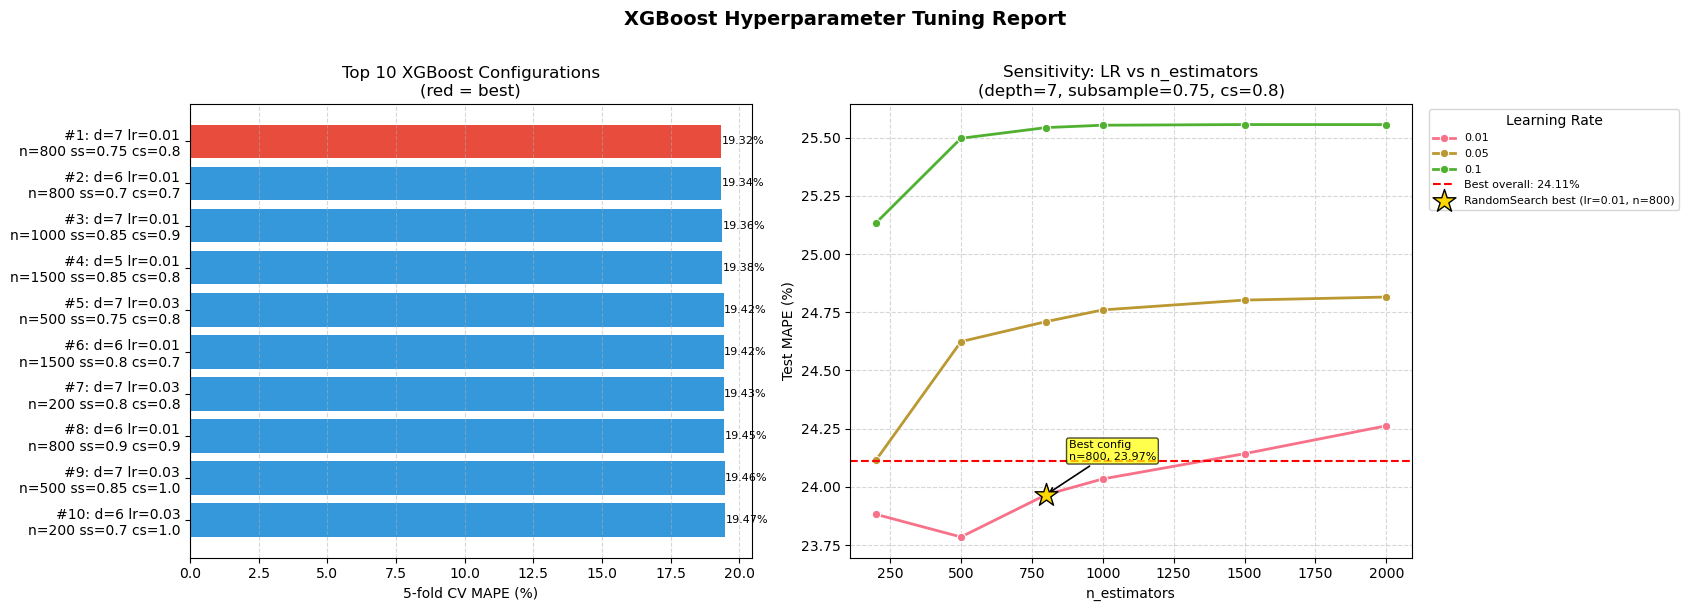

In [10]:
import matplotlib.gridspec as gridspec

# ══════════════════════════════════════════════════════════════════════════
# XGBoost Hyperparameter Tuning Report
# ══════════════════════════════════════════════════════════════════════════
print("=" * 65)
print("   XGBOOST HYPERPARAMETER TUNING REPORT")
print("   Loss: Huber (reg:pseudohubererror)  |  Search: RandomizedSearchCV")
print("   Scoring: MAPE in actual dollar space (exp-converted log predictions)")
print("   Candidates: 50  |  CV folds: 5  |  Total fits: 250")
print("=" * 65)

print("\n[1] BEST CONFIGURATION")
print("-" * 40)
for k, v in sorted(best_params.items()):
    print(f"   {k:<22}: {v}")
print(f"\n   Train MAPE : {best_row['Train_MAPE%']:.2f}%")
print(f"   Test  MAPE : {best_row['Test_MAPE%']:.2f}%")

print("\n[2] TOP 10 CONFIGURATIONS (by 5-fold CV MAPE)")
print("-" * 70)
top10 = cv_results[['param_max_depth', 'param_learning_rate',
                     'param_n_estimators', 'param_subsample',
                     'param_colsample_bytree', 'CV_MAPE%']].head(10).copy()
top10.columns = ['max_depth', 'learning_rate', 'n_estimators',
                  'subsample', 'colsample_bytree', 'CV_MAPE%']
top10 = top10.reset_index(drop=True)
top10.index += 1
print(top10.to_string())
print("-" * 70)

# ── Figure: Top-10 bar chart (left) + sensitivity line plot (right) ────────
fig, axes = plt.subplots(1, 2, figsize=(17, 6))

bar_labels = [
    f"#{i}: d={int(r['max_depth'])} lr={r['learning_rate']}\n"
    f"n={int(r['n_estimators'])} ss={r['subsample']} cs={r['colsample_bytree']}"
    for i, r in top10.iterrows()
]
bar_colors = ['#e74c3c' if i == 1 else '#3498db' for i in range(1, 11)]
axes[0].barh(bar_labels, top10['CV_MAPE%'], color=bar_colors)
axes[0].invert_yaxis()
axes[0].set_xlabel('5-fold CV MAPE (%)')
axes[0].set_title('Top 10 XGBoost Configurations\n(red = best)', fontsize=12)
axes[0].grid(axis='x', linestyle='--', alpha=0.5)
for i, val in enumerate(top10['CV_MAPE%']):
    axes[0].text(val + 0.02, i, f'{val:.2f}%', va='center', fontsize=8)

sns.lineplot(data=tuning_df, x='N_Estimators', y='Test_MAPE%',
             hue='Learning_Rate', marker='o', linewidth=2, ax=axes[1])

# ── Red dashed line: best overall Test MAPE from RandomizedSearch ──────────
axes[1].axhline(best_row['Test_MAPE%'], color='red', linestyle='--', linewidth=1.5,
                label=f"Best overall: {best_row['Test_MAPE%']:.2f}%")

# ── Gold star: mark the exact (lr, n_estimators) of the best config ────────
best_lr_str = str(float(best_params['learning_rate']))   # match tuning_df string format
best_n      = best_params['n_estimators']

# Find the row in tuning_df that matches the best config's lr and n_estimators
best_point = tuning_df[
    (tuning_df['Learning_Rate'] == best_lr_str) &
    (tuning_df['N_Estimators']  == best_n)
]
# Normalise lr string to match tuning_df format (e.g. 0.01 → '0.01')
best_lr_str = str(best_params['learning_rate'])   # tuning_df stores str(lr) directly

if not best_point.empty:
    bx = float(best_point['N_Estimators'].values[0])
    by = float(best_point['Test_MAPE%'].values[0])
    axes[1].scatter(bx, by, color='gold', s=300, edgecolors='black',
                    zorder=7, marker='*',
                    label=f"RandomSearch best (lr={best_params['learning_rate']}, n={best_n})")
    axes[1].annotate(
        f"Best config\nn={best_n}, {by:.2f}%",
        xy=(bx, by), xytext=(bx + 80, by + 0.15),
        arrowprops=dict(arrowstyle='->', color='black', lw=1.2),
        fontsize=8, ha='left',
        bbox=dict(boxstyle='round,pad=0.2', fc='yellow', alpha=0.7)
    )
else:
    axes[1].axvline(best_n, color='gold', linestyle=':', linewidth=2,
                    label=f"RandomSearch best n={best_n} (not in grid)")

axes[1].set_title(f"Sensitivity: LR vs n_estimators\n"
                  f"(depth={best_params['max_depth']}, "
                  f"subsample={best_params['subsample']}, "
                  f"cs={best_params.get('colsample_bytree', 0.8)})",
                  fontsize=12)
axes[1].set_xlabel('n_estimators')
axes[1].set_ylabel('Test MAPE (%)')
axes[1].legend(title='Learning Rate', fontsize=8,
               bbox_to_anchor=(1.02, 1), loc='upper left')
axes[1].grid(linestyle='--', alpha=0.5)

plt.suptitle('XGBoost Hyperparameter Tuning Report',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


## 9. Accuracy Plot (Actual vs Predicted)

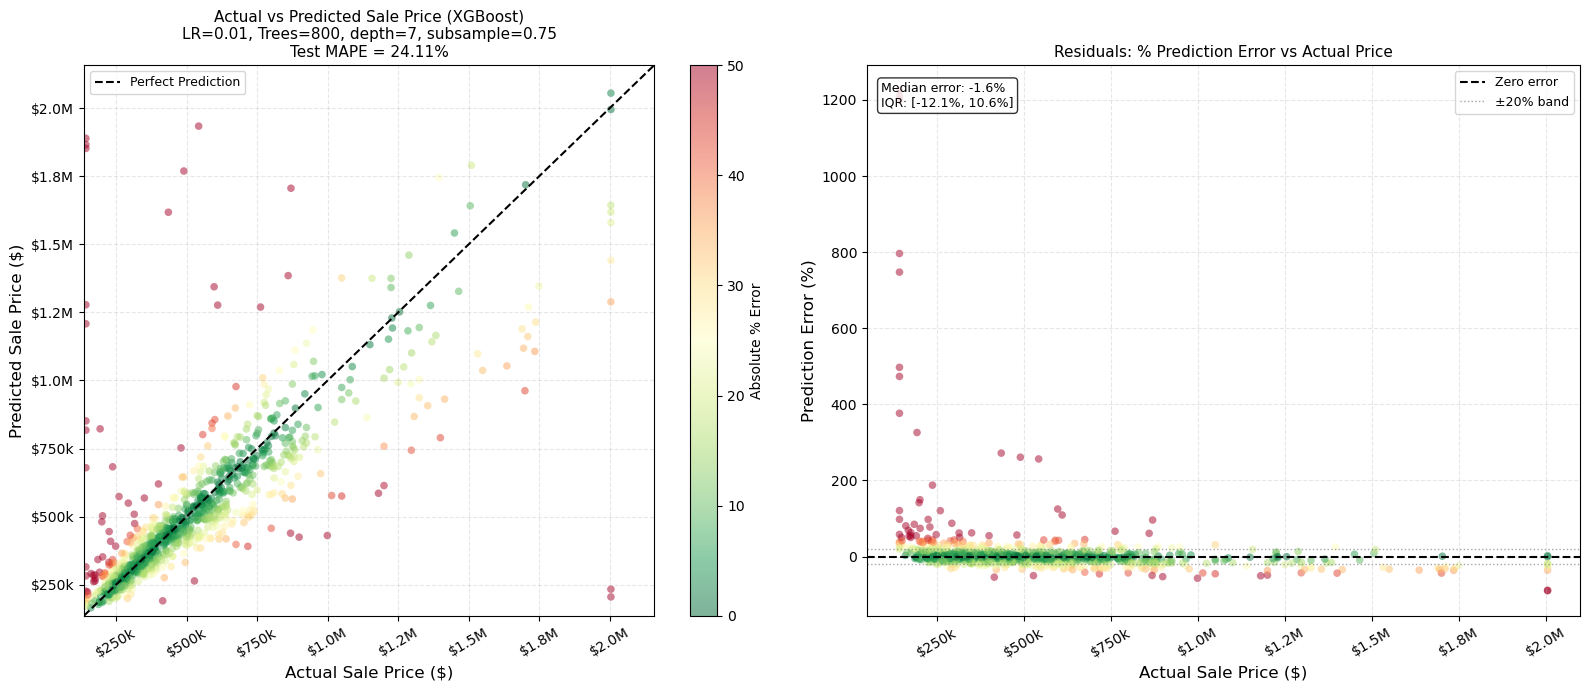


Prediction summary (test set, n=921):
  Median % error : -1.58%
  IQR            : [-12.07%, 10.65%]
  Within ±10%    : 45.6% of predictions
  Within ±20%    : 72.5% of predictions
  Within ±30%    : 86.6% of predictions


In [17]:
# Accuracy plot (Actual vs Predicted) for the best XGBoost model
# Linear scale — shows true dollar spread without log compression
import matplotlib.ticker as ticker

best_xgb_model = best_xgb

# Clip before exp() to prevent overflow (log-price predictions should be ~11–14)
y_pred_dollars   = np.exp(np.clip(best_xgb_model.predict(X_test), 5, 20)).ravel()
y_actual_dollars = np.ravel(y_test_actual)

# ── Compute residuals for colour-coding ────────────────────────────────────
pct_error = (y_pred_dollars - y_actual_dollars) / y_actual_dollars * 100  # signed %
abs_error = np.abs(pct_error)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# ── Left: Actual vs Predicted (linear scale) ──────────────────────────────
sc = axes[0].scatter(
    y_actual_dollars, y_pred_dollars,
    c=abs_error, cmap='RdYlGn_r', vmin=0, vmax=50,
    alpha=0.5, edgecolors='none', s=30
)
plt.colorbar(sc, ax=axes[0], label='Absolute % Error')

# Perfect prediction line
lim_min = min(y_actual_dollars.min(), y_pred_dollars.min()) * 0.95
lim_max = max(y_actual_dollars.max(), y_pred_dollars.max()) * 1.05
axes[0].plot([lim_min, lim_max], [lim_min, lim_max], 'k--', lw=1.5,
             label='Perfect Prediction')

# ±20% bands
# axes[0].plot([lim_min, lim_max], [lim_min*0.8, lim_max*0.8],
#              color='grey', lw=1, linestyle=':', alpha=0.7, label='±20% band')
# axes[0].plot([lim_min, lim_max], [lim_min*1.2, lim_max*1.2],
#              color='grey', lw=1, linestyle=':', alpha=0.7)

axes[0].set_xlim(lim_min, lim_max)
axes[0].set_ylim(lim_min, lim_max)
axes[0].set_title(
    f"Actual vs Predicted Sale Price (XGBoost)\n"
    f"LR={best_params['learning_rate']}, Trees={best_params['n_estimators']}, "
    f"depth={best_params['max_depth']}, subsample={best_params['subsample']}\n"
    f"Test MAPE = {best_row['Test_MAPE%']:.2f}%",
    fontsize=11
)
axes[0].set_xlabel('Actual Sale Price ($)', fontsize=12)
axes[0].set_ylabel('Predicted Sale Price ($)', fontsize=12)
axes[0].legend(fontsize=9)
axes[0].grid(True, linestyle='--', alpha=0.3)

# Format tick labels as $500k / $1.2M
formatter = ticker.FuncFormatter(
    lambda x, pos: f'${x/1e6:.1f}M' if x >= 1e6 else f'${x/1e3:.0f}k'
)
axes[0].xaxis.set_major_formatter(formatter)
axes[0].yaxis.set_major_formatter(formatter)
axes[0].tick_params(axis='x', rotation=30)

# ── Right: Residual plot (% error vs Actual price) ────────────────────────
axes[1].scatter(y_actual_dollars, pct_error,
                c=abs_error, cmap='RdYlGn_r', vmin=0, vmax=50,
                alpha=0.5, edgecolors='none', s=30)
axes[1].axhline(0,   color='black', lw=1.5, linestyle='--', label='Zero error')
axes[1].axhline( 20, color='grey',  lw=1,   linestyle=':',  alpha=0.7, label='±20% band')
axes[1].axhline(-20, color='grey',  lw=1,   linestyle=':',  alpha=0.7)

axes[1].set_title('Residuals: % Prediction Error vs Actual Price', fontsize=11)
axes[1].set_xlabel('Actual Sale Price ($)', fontsize=12)
axes[1].set_ylabel('Prediction Error (%)', fontsize=12)
axes[1].xaxis.set_major_formatter(formatter)
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(fontsize=9)
axes[1].grid(True, linestyle='--', alpha=0.3)

# Annotate median / IQR of error
med_err = np.median(pct_error)
p25, p75 = np.percentile(pct_error, [25, 75])
axes[1].text(0.02, 0.97,
    f"Median error: {med_err:+.1f}%\nIQR: [{p25:.1f}%, {p75:.1f}%]",
    transform=axes[1].transAxes, va='top', fontsize=9,
    bbox=dict(boxstyle='round', fc='white', alpha=0.8))

plt.tight_layout()
plt.show()

print(f"\nPrediction summary (test set, n={len(y_actual_dollars)}):")
print(f"  Median % error : {med_err:+.2f}%")
print(f"  IQR            : [{p25:.2f}%, {p75:.2f}%]")
print(f"  Within ±10%    : {(abs_error <= 10).mean()*100:.1f}% of predictions")
print(f"  Within ±20%    : {(abs_error <= 20).mean()*100:.1f}% of predictions")
print(f"  Within ±30%    : {(abs_error <= 30).mean()*100:.1f}% of predictions")


## 10. Feature Importance

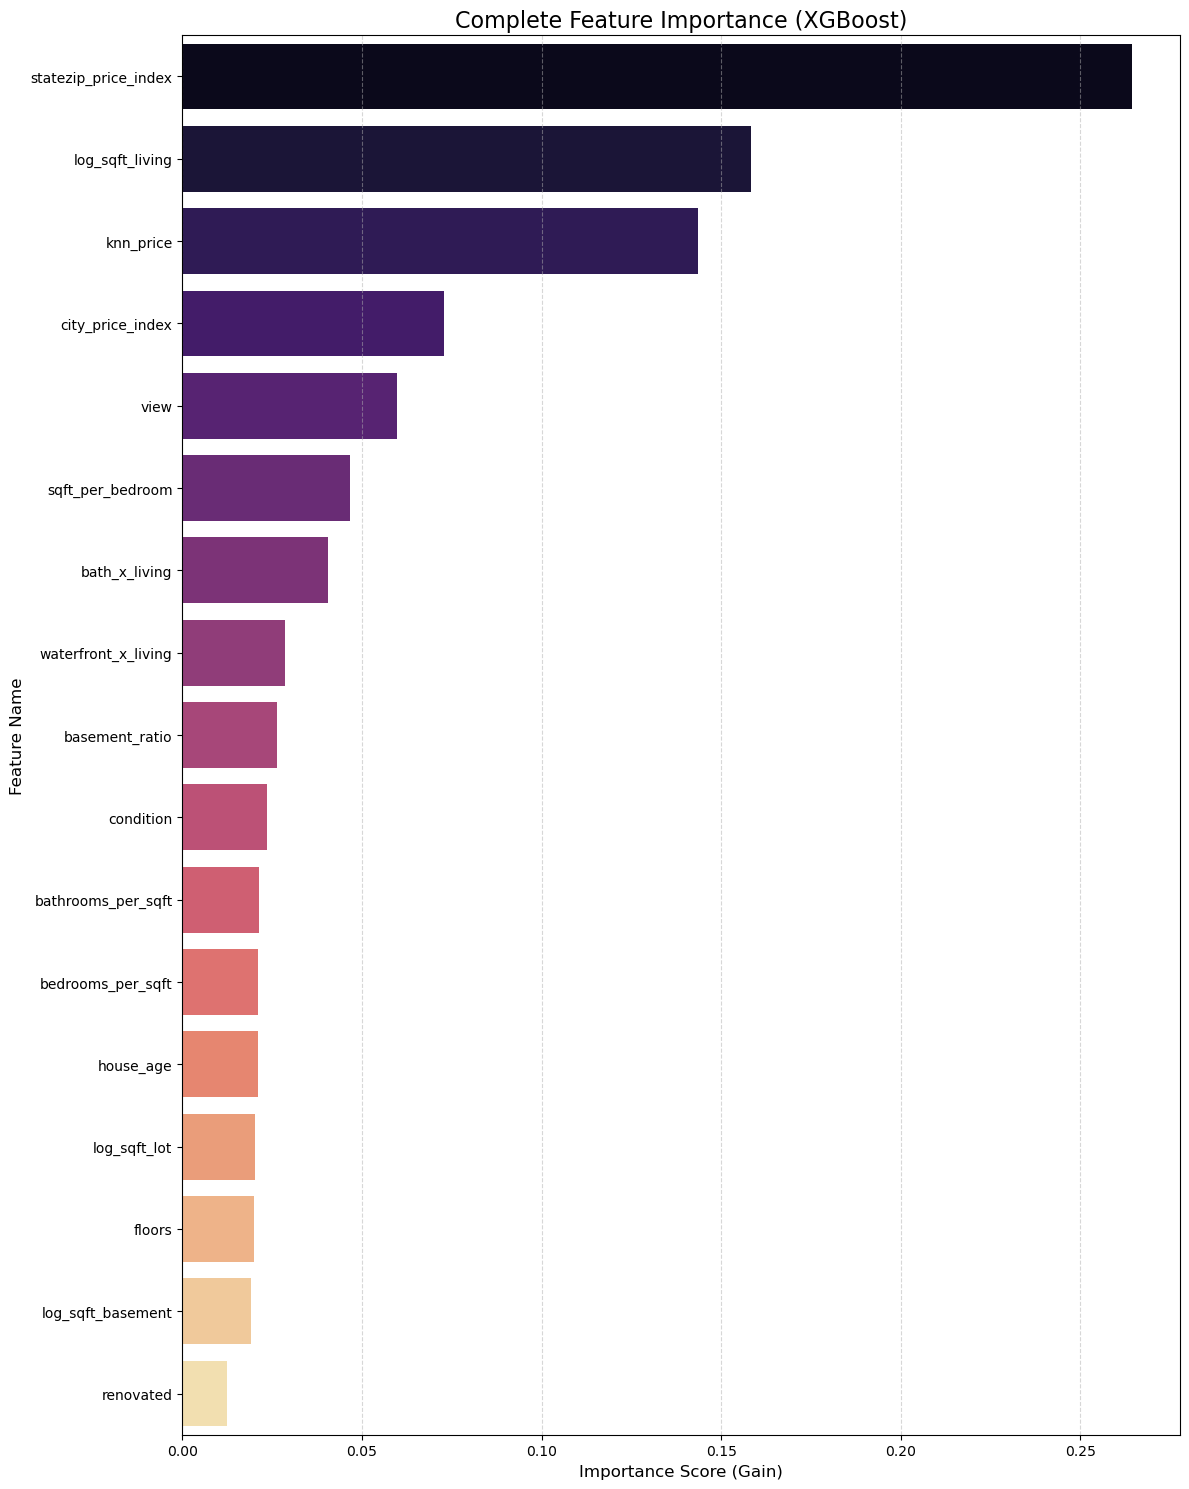

Total Features Analyzed: 17
                 Feature  Importance
0   statezip_price_index    0.264499
1        log_sqft_living    0.158195
2              knn_price    0.143623
3       city_price_index    0.072812
4                   view    0.059795
5       sqft_per_bedroom    0.046563
6          bath_x_living    0.040465
7    waterfront_x_living    0.028713
8         basement_ratio    0.026431
9              condition    0.023714
10    bathrooms_per_sqft    0.021437
11     bedrooms_per_sqft    0.021079
12             house_age    0.020940
13          log_sqft_lot    0.020213
14                floors    0.020000
15     log_sqft_basement    0.019091
16             renovated    0.012432


In [18]:
#Feature Importance Code (Plot and Table) (XGBoost)
# 1. Extract and sort all features
feature_names = X_train.columns
importances = best_xgb_model.feature_importances_

fi_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# 2. Adjust figure height based on the number of features
# If you have 30 features, height=12 or 15 is usually good.
plt.figure(figsize=(12, 15)) 

# 3. Create the barplot for the entire DataFrame
sns.barplot(
    data=fi_df, 
    x='Importance', 
    y='Feature', 
    hue='Feature',
    palette='magma',
    legend=False
)

# 4. Professional Formatting
plt.title('Complete Feature Importance (XGBoost)', fontsize=16)
plt.xlabel('Importance Score (Gain)', fontsize=12)
plt.ylabel('Feature Name', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# 5. Full Table for Appendix
# This is often useful for the technical appendix of your report
print(f"Total Features Analyzed: {len(fi_df)}")
print(fi_df.reset_index(drop=True))